# Загрузка данных

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

from sklearn.feature_selection import RFE
from sklearn.feature_selection import SelectKBest, f_regression

In [143]:
%%capture
!wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [ ]:
data = pd.read_excel('data_ford_price.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         7017 non-null   int64  
 1   year          7017 non-null   int64  
 2   condition     7017 non-null   int64  
 3   cylinders     7017 non-null   int64  
 4   odometer      7017 non-null   int64  
 5   title_status  7017 non-null   object 
 6   transmission  7017 non-null   object 
 7   drive         6626 non-null   object 
 8   size          5453 non-null   object 
 9   lat           7017 non-null   float64
 10  long          7017 non-null   float64
 11  weather       6837 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 658.0+ KB


#  Отбор числовых признаков

## Предобработка данных

In [145]:
# Выбираем числовые непрерывные
data = data[['price','year', 'cylinders', 'odometer', 'lat', 'long', 'weather']]

# Удаляем пропуски
data.dropna(inplace = True)

# Выделяем целевую
y = data['price']
X = data.drop('price', axis=1)

# Выделяем тестовые данные 30/70
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

## Обучение модели без отбора признаков

In [146]:
# Линейна регрессия на числовых данных
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 4787.651


## Отбор признаков на основе анализа мультиколлинеарности

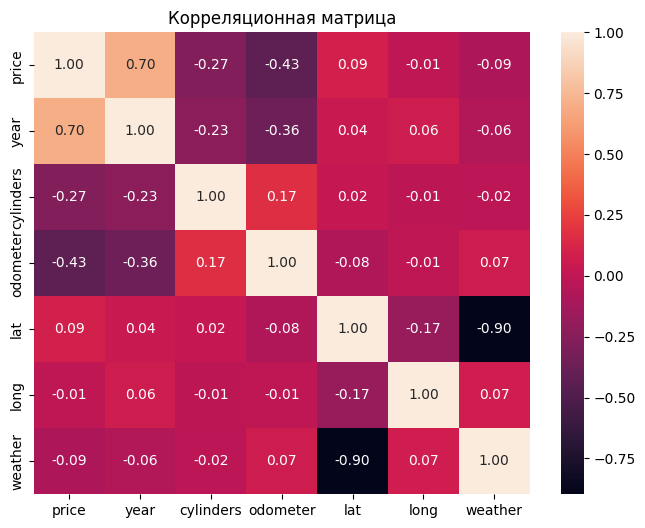

In [147]:
# Вычисляем корреляцию
corr_matrix = data.corr()

# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

In [148]:
# Удаляю избыточный признак
X.drop('lat', axis = 1, inplace = True)

# Обновляю трейн и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

# Линейна регрессия на числовых данных
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 4774.656


## Метод рекурсивного исключения признаков

In [149]:
# Выделяем целевую
y = data['price']
X = data.drop('price', axis=1)

# Выделяем тестовые данные 30/70
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

# Обучаем модель и делаем отбор 3 признаков
model = LinearRegression()
selector = RFE(model, n_features_to_select=3, step=1)
selector = selector.fit(X_train, y_train)

# Применяем отбор к обоим наборам
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)
print('Выбранные признаки:', selector.get_feature_names_out())

# Обучаем и оцениваем на отобранных признаках
model.fit(X_train_selected, y_train)
y_predicted = model.predict(X_test_selected)
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

Выбранные признаки: ['year' 'cylinders' 'lat']
MAE: 5156.388


##  Метод выбора признаков на основе фильтров

In [150]:
# Обучаем модель и делаем отбор 3 признаков
model = LinearRegression()
selector = SelectKBest(f_regression, k=3)
selector = selector.fit(X_train, y_train)

# Применяем отбор к обоим наборам
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)
print('Выбранные признаки:', selector.get_feature_names_out())

# Обучаем и оцениваем на отобранных признаках
model.fit(X_train_selected, y_train)
y_predicted = model.predict(X_test_selected)
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

Выбранные признаки: ['year' 'cylinders' 'odometer']
MAE: 4787.516


# Вывод

Результаты моделей:
1. Все признаки: MAE = 4787.651
2. После удаления избыточного признака (lat): MAE = 4774.656  
3. RFE метод: MAE = 5156.388 (признаки: year, cylinders, lat)
4. SelectKBest метод: MAE = 4787.516 (признаки: year, cylinders, odometer)

Модель после удаления избыточного признака (lat) показала лучший результат с MAE = 4774.656, что немного лучше, чем модель со всеми признаками. SelectKBest метод показал результат, практически идентичный модели со всеми признаками (MAE = 4787.516), что говорит о его эффективности в выборе информативных признаков. RFE метод показал наихудший результат (MAE = 5156.388), вероятно из-за включения слабого признака 'lat' вместо более информативного 'odometer', в отличие от метода KBest. Однако, если проводить RFE без признака lat, модель выбирает наиболее важным признаком weather. Ни lat ни weather не показывают какой-либо значимой корреляционной связи с целевой переменной на тепловой карте, соответственно, линейная модель, построенная на этих признаках, дает наихудший результат. В целом, если бы я выбирала признаки по тепловой карте сравнивая корреляции признаков с целевой, выбрала бы те же признаки, что были выбраны в KBest методе.